In [1]:
import skeliner as sk

In [2]:
mesh = sk.io.load_mesh("./data/720575940552805191.obj")

In [3]:
# 1. Parallel patches
patches = sk.pre.find_parallel_patches(mesh, verbose=True)
if patches:
    mesh = sk.pre.remove_parallel_patches(mesh, patches=patches, verbose=True)

[skeliner.pre] Finding parallel patches …
[skeliner.pre] Parallel patches: 1 patches, 3 faces (X:1) at 11 boundaries (1.4s)
[skeliner.pre] Removing parallel patches …
[skeliner.pre] remove_parallel_patches: removed 3f (1 fold + 0 parallel) (3.6s)


In [4]:
# 2. Organelles
organelles, mesh_stats = sk.pre.find_organelles(mesh, return_mesh_stats=True, verbose=True)

[skeliner.pre] Finding organelles …
[skeliner.pre] Computing mesh stats …
[skeliner.pre] Mesh stats: 149 components, radius=546, raw internal=141,894 (31.1%) (8.6s)
[skeliner.pre] Finding isolated organelles …
[skeliner.pre] Isolated organelles: 148 fragments, 36,266 faces (0 external kept; 127 by dots, 21 by geometry) (0.1s)
[skeliner.pre] Finding pocket organelles …
[skeliner.pre] Pocket organelles: 117,440 faces from 132 mouths (fill 93,843, bridge +1, holes +24,908, rejected 17) (2.5s)
[skeliner.pre] find_organelles: pocket=124,359, isolated=36,266, 2 structural components, enclosed +6,919 (12.1s)


[skeliner.pre] Finding soma …
[skeliner.pre] Soma: nucleus=[539313, 517150, 76818] r=2800 z=[73458–80178]; ellipsoid axes=[5941, 4973, 3943], 44,723 verts, cutoff ring 57/367 (2.0s)


(<Figure size 800x800 with 4 Axes>,
 [<Axes: title={'center': 'XY'}, xlabel='x', ylabel='y'>,
  <Axes: title={'center': 'XZ'}, xlabel='x', ylabel='z'>,
  <Axes: title={'center': 'ZY'}, xlabel='z', ylabel='y'>])

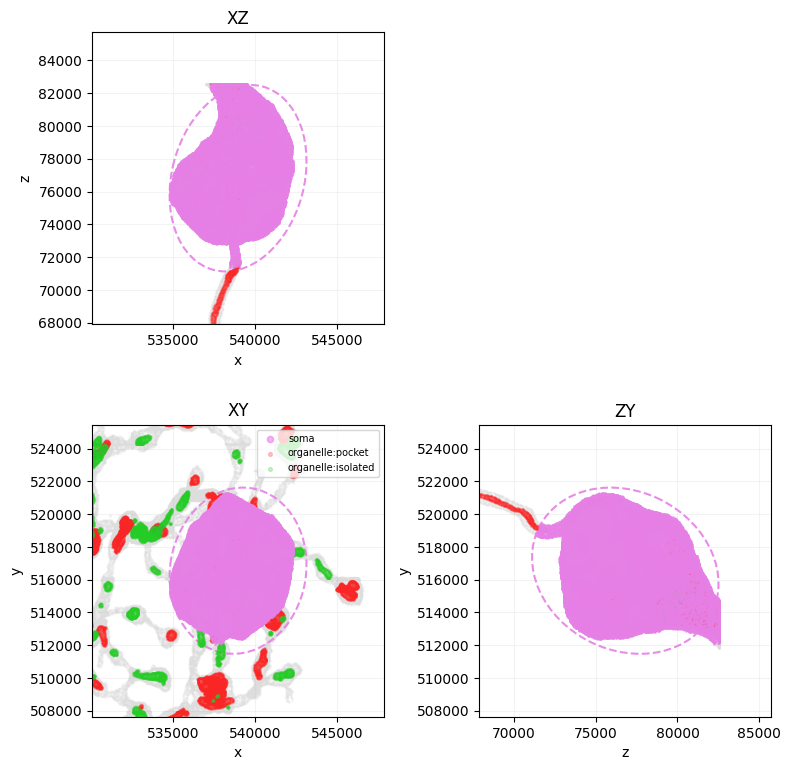

In [5]:
# 3. Soma
soma = sk.pre.find_soma_via_ring_cutoff(mesh, organelles=organelles, mesh_stats=mesh_stats, verbose=True)
sk.plot.vis2d.diagnose_soma(mesh=mesh, soma=soma, organelles=organelles, figsize=(8,8))

In [ ]:
# 4. Fusions → Disconnected → gaps
fusions = sk.pre.find_fusions(mesh, mesh_stats=mesh_stats, verbose=True)

disconnected = sk.pre.find_disconnected(mesh, soma=soma, organelles=organelles, fusions=fusions, mesh_stats=mesh_stats, verbose=True)

gaps = sk.pre.find_gaps(mesh, soma=soma, disconnected=disconnected, fusions=fusions, mesh_stats=mesh_stats, verbose=True)
if gaps:
    mesh = sk.pre.remove_gaps(mesh, gaps=gaps, mesh_stats=mesh_stats, verbose=True)

[skeliner.pre] Mesh: 456,780 faces, 247 zero-area, 9 non-manifold edges
[skeliner.pre] Scanning 227,948 vertices for fan fusions ...
[skeliner.pre]   Fan vertex 26113: 2 components, sizes [7, 3]
[skeliner.pre]   Fan vertex 148226: 2 components, sizes [3, 2]
[skeliner.pre]   Fan vertex 183206: 2 components, sizes [7, 2]
[skeliner.pre]   Fan vertex 197700: 3 components, sizes [6, 2, 1]
[skeliner.pre]   Fan vertex 198210: 2 components, sizes [4, 2]
[skeliner.pre]   Fan vertex 208799: 2 components, sizes [6, 5]
[skeliner.pre] Fusions: scanned 227,948 vertices, 6 fan fusions found
[skeliner.pre] Fusion seeds: 5 clusters, 21 faces (nm_neg=18, dupes=6, fan_verts=6)
[skeliner.pre] Growing seed cluster 1/5 (9f) ...
[skeliner.pre]   ring 3: 46f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 4: 71f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 5: 103f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 6: 147f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 7: 195f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 8: 253f, 3 comps (1

In [ ]:
# 5. Remove fusions
if fusions:
    mesh = sk.pre.remove_fusions(mesh, fusions=fusions, mesh_stats=mesh_stats, verbose=True)

[skeliner.pre] Mesh: 456,780 faces, 247 zero-area, 9 non-manifold edges
[skeliner.pre] Scanning 227,948 vertices for fan fusions ...
[skeliner.pre]   Fan vertex 26113: 2 components, sizes [7, 3]
[skeliner.pre]   Fan vertex 148226: 2 components, sizes [3, 2]
[skeliner.pre]   Fan vertex 183206: 2 components, sizes [7, 2]
[skeliner.pre]   Fan vertex 197700: 3 components, sizes [6, 2, 1]
[skeliner.pre]   Fan vertex 198210: 2 components, sizes [4, 2]
[skeliner.pre]   Fan vertex 208799: 2 components, sizes [6, 5]
[skeliner.pre] Fusions: scanned 227,948 vertices, 6 fan fusions found
[skeliner.pre] Fusion seeds: 5 clusters, 21 faces (nm_neg=18, dupes=6, fan_verts=6)
[skeliner.pre] Growing seed cluster 1/5 (9f) ...
[skeliner.pre]   ring 3: 46f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 4: 71f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 5: 103f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 6: 147f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 7: 195f, 3 comps (1 >= 5f)
[skeliner.pre]   ring 8: 253f, 3 comps (1

In [ ]:
# 6. Break up mesh
if soma is not None:
    components = sk.pre.break_up_mesh(mesh, soma, organelles, verbose=True)

break_up_mesh: absorbed 183 faces (140 verts) as missed soma
break_up_mesh: 1 neurites, 0 discarded (0 faces, threshold ~207947 faces), soma 44,852 verts, organelles 160,625 faces


In [ ]:
# 7. Optional Mesh Compaction (remove degenerated faces and reindex everything, not truly necessary)
# mesh, components = sk.pre.compact_mesh(mesh, components=components, verbose=True)

In [ ]:
# Or run the entire pipeline in one call:
mesh, components = sk.preprocess(mesh, compact=True, verbose=True)

[skeliner.pre] starting preprocessing (885,995 vertices, 1,772,047 faces)
 ↳  find & remove parallel patches               … 25.77 s
 ↳  find organelles                              … 53.99 s
      └─ pocket=239,572, isolated=94,544
 ↳  find soma                                    … 20.43 s
      └─ center=[845456.0, 474681.0, 26789.0]
 ↳  find fusions                                 … 15.09 s
      └─ 73 fusions
 ↳  find disconnected                            … 7.58 s
 ↳  find & remove gaps                           … 75.26 s
      └─ 29 gaps
 ↳  remove fusions                               … 14.43 s
 ↳  break up mesh                                … 18.86 s
      └─ 4 neurites
 ↳  compact mesh                                 … 0.22 s
[skeliner.pre] preprocessing done (1,773,092 faces, 231.6s)


(<Figure size 800x800 with 4 Axes>,
 [<Axes: title={'center': 'XY'}, xlabel='x', ylabel='y'>,
  <Axes: title={'center': 'XZ'}, xlabel='x', ylabel='z'>,
  <Axes: title={'center': 'ZY'}, xlabel='z', ylabel='y'>])

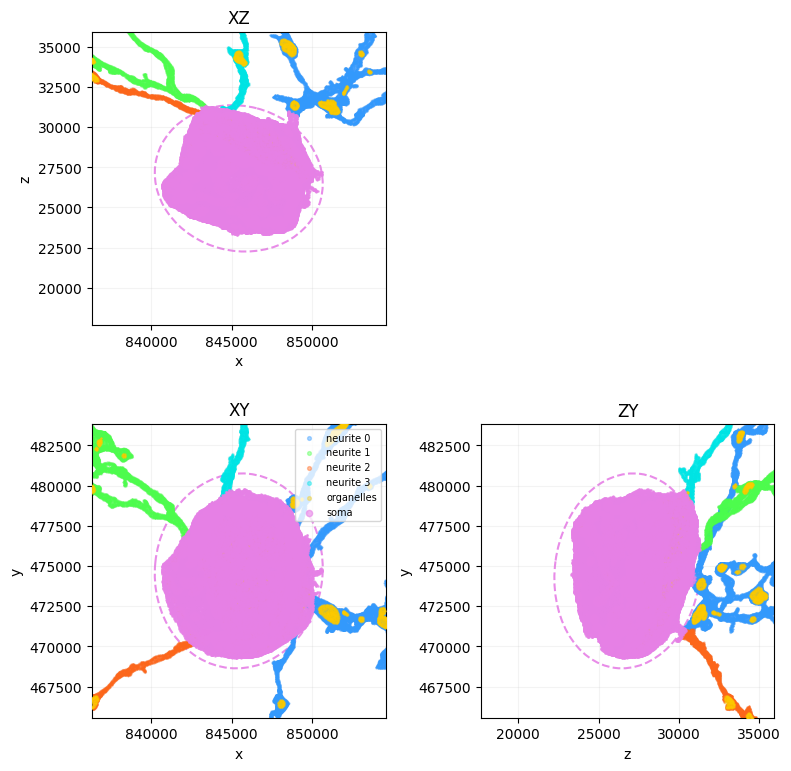

In [ ]:
sk.plot.vis2d.diagnose_components(mesh=mesh, components=components, figsize=(8,8))

In [ ]:
# # save mesh and components
sk.io.save_mesh(mesh=mesh, path="./data/mesh_cleaned.obj")
sk.io.save_components(components, path="./data/components.npz")


In [ ]:
%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark

Last updated: 2026-04-10 11:22:26 CEST

Python implementation: CPython
Python version       : 3.13.11
IPython version      : 9.12.0

skeliner: 0.3.0

Watermark: 2.6.0

